# ViEVOLVEdi

## Objetivo

Este proyecto es un generador evolutivo de melodías utilizando algoritmos genéticos. Permite a los usuarios configurar parámetros como el rango de notas, la longitud de la melodía, el tamaño de la población, las tasas de cruce y mutación, y el elitismo. El objetivo es crear melodías que sean musicalmente "agradables" y variadas.

## Propuesta

### SMF: Standard MIDI File

> No confundir con MIDI, que es un protocolo de comunicación entre instrumentos musicales electrónicos.

Un SMF es un archivo que sigue el estándar MIDI para almacenar estas instrucciones musicales, es decir, notas, ritmo y tempo, en lugar de datos de audio. Los archivos SMF son ampliamente utilizados en la producción musical, la composición y la educación musical debido a su capacidad para representar música de manera compacta y flexible.

Los archivos MIDI estándar pueden estar en estos tres formatos:

- **Formato 0**: Contiene una sola pista que almacena todos los eventos MIDI. Es el formato más simple y se utiliza principalmente para archivos MIDI pequeños o simples.

- **Formato 1**: Contiene múltiples pistas, donde cada pista puede representar diferentes instrumentos o partes de una composición musical. Este formato es más común y permite una mayor complejidad en la representación musical.

- **Formato 2**: También contiene múltiples pistas, pero cada pista puede representar una composición musical independiente. Este formato es menos común y se utiliza principalmente para aplicaciones especializadas.

#### MIDI Formato 0

En nuestro caso, utlizaremos el **Formato 0** para guardar las melodías generadas.

Aquí un ejjemplo de la estructura de un archivo MIDI en Formato 0:

    4D 54 68 64 00 00 00 06 00 00 00 01 00 60
    4D 54 72 6B 00 00 00 19
    00 C0 00
    00 90 3C 64
    81 40 80 3C 40  
    00 FF 2F 00

Un archivo MIDI 0 siempre contiene dos bloques principales:

##### Header Chunk (MThd)

    4D 54 68 64 00 00 00 06 00 00 00 01 00 60

Donde:

- 4D 54 68 64: Identificador del encabezado "MThd"
- 00 00 00 06: Tamaño del encabezado (6 bytes)
- 00 00: Formato del archivo (0)
- 00 01: Número de pistas (1)
- 00 60: División de tiempo (96 ticks por negra)

##### Track Chunk (MTrk) — solo uno (porque es formato 0)


4D 54 72 6B: Identificador "MTrk"
00 00 00 19: Tamaño del track (25 bytes)

Posteriormente, se incluyen los eventos MIDI que definen la melodía.

    00 C0 00           ; [tiempo 0] Program Change → Instrumento 0 (Piano)
    00 90 3C 64        ; [tiempo 0] Note ON → nota 3C (Do4), velocity 100
    81 40              ; delta-time (espera aprox. 192 ticks)
    80 3C 40           ; Note OFF → Do4, velocity 64
    00 FF 2F 00        ; End of Track

Notemos entonces que los eventos, en este caso que son Note ON y Note OFF, están precedidos por un valor de delta-time que indica cuánto tiempo esperar antes de ejecutar el evento, Delta-time + Evento y que es medido en ticks.

Ejemplo: Si el delta-time es 81 40 (en hexadecimal), esto se traduce a 192 ticks. Si la división de tiempo es 96 ticks por negra, entonces 192 ticks equivalen a 2 negras.

### Encoding 

Dado que representar melodías directamente en formato MIDI es complejo, se opta por una representación simplificada para el proceso evolutivo. En el encoding propuesto, cada melodía se representa con una secuencia de pares (nota, duración), donde: - **Nota**: Un valor entero que representa la nota MIDI (por ejemplo, 60 para Do4, 61 para Do#4, etc.). Se utiliza 0 para indicar un silencio. - **Duración**: Un valor flotante que representa la duración rítmica de la nota (por ejemplo, 0.25 para una semicorchea, 0.5 para una corchea, 1.0 para una negra, etc.).

Utilizamos la siguiente clase para el encoding que hereda de la clase base `Encoding` de MetaZoo.

```python
class MelodyEncoding(Encoding):
    """
    Codifica una melodía como una secuencia de notas MIDI y duraciones rítmicas, incluyendo silencios.
    Usa 0 como nota para indicar silencio.
    """
    def __init__(self, note_range: Tuple[int, int] = (60, 72), durations: Tuple[float, ...] = (0.25, 0.5, 1.0, 2.0), length: int = 64, silence_prob: float = 0.2):
        self.note_range = note_range
        self.durations = durations
        self.length = length
        self.genome_length = length
        self.silence_prob = silence_prob

    def encode(self, population_size: int) -> np.ndarray:
        notes = np.random.randint(self.note_range[0], self.note_range[1], size=(population_size, self.length))
        # Asigna silencios aleatoriamente
        silence_mask = np.random.rand(population_size, self.length) < self.silence_prob
        notes[silence_mask] = 0
        durations = np.random.choice(self.durations, size=(population_size, self.length))
        return np.stack((notes, durations), axis=-1)

    def decode(self, individual: np.ndarray) -> np.ndarray:
        return individual
```

Notemos que para la generación inicial de la población, lo hacemos de manera aleatoria, asignando notas dentro del rango especificado y duraciones de una lista predefinida. Además, se introduce una probabilidad de silencio para diversificar las melodías.

Entonces, un individuo de la población podría verse así:

```python

array([[71.  ,  0.5 ],
       [64.  ,  2.  ],
       [61.  ,  1.  ],
       [ 0.  ,  1.  ],
       [66.  ,  1.  ],
       [65.  ,  0.25],
       [66.  ,  0.25],
       [69.  ,  0.25],
       [65.  ,  2.  ],
       [67.  ,  0.25],
       [ 0.  ,  0.25],
       [65.  ,  0.5 ],
       [64.  ,  0.25],
       [71.  ,  0.25],
       [60.  ,  2.  ],
       [ 0.  ,  1.  ]])

```

### Operadores Genéticos

Ahora necesitamos implementar operadores de cruce y mutación específicos para este tipo de encoding. El cruce combina segmentos de dos melodías padres, mientras que la mutación altera aleatoriamente notas o duraciones en una melodía.

```python
class MelodyOperators:
    @staticmethod
    def crossover(parent1, parent2):
        # Dos puntos de corte para mayor variedad
        p1, p2 = sorted(np.random.choice(range(1, len(parent1)), 2, replace=False))
        child1 = np.vstack((parent1[:p1], parent2[p1:p2], parent1[p2:]))
        child2 = np.vstack((parent2[:p1], parent1[p1:p2], parent2[p2:]))
        return child1, child2

    @staticmethod
    def mutation(individual, note_range=(60,72), durations=(0.25,0.5,1.0,2.0), silence_prob=0.05):
        idx = np.random.randint(len(individual))
        # Evita mutar a silencio si ya hay muchos
        if np.random.rand() < silence_prob and sum(individual[:,0]==0)/len(individual) < 0.3:
            individual[idx, 0] = 0
        else:
            individual[idx, 0] = np.random.randint(note_range[0], note_range[1])
        individual[idx, 1] = np.random.choice(durations)
        return individual
```

El cross over utiliza dos puntos de corte para combinar segmentos de dos padres y crear dos hijos. La mutación selecciona una posición aleatoria en la melodía y cambia la nota o duración, con una probabilidad de introducir un silencio, siempre y cuando no haya demasiados silencios ya presentes.

### Función Objetivo

La función objetivos es el "corazón" del proceso evolutivo, ya que define qué tan "buena" es una melodía generada. Optimizar una melodía implica evaluar múltiples aspectos musicales que contribuyen a su calidad percibida, por lo que se trata de un problema multiobjetivo. No obstante, uno de los problemas más complejos en la implementación de la función objetivo es la cuantificación de aspectos musicales subjetivos como la "agradabilidad". Sin embargo, podemos considerar varios aspectos objetivos que contribuyen a la calidad de una melodía, tales como:

- **Diversidad**: Variedad de notas utilizadas en la melodía.
- **Variación rítmica**: Diversidad en las duraciones de las notas.
- **Rango de alturas**: Diferencia entre la nota más alta y la más baja.
- **Densidad temporal**: Cantidad de notas por unidad de tiempo.
- **Variación de contorno**: Cambios en la dirección melódica (ascendente/descendente).
- **Variedad intervalica**: Diversidad de intervalos entre notas consecutivas.
- **Índice de sincopación**: Presencia de ritmos sincopados.
- **Estabilidad tonal**: Proximidad a una tonalidad específica.
- **Repetición motívica**: Presencia de motivos melódicos repetidos.
- **Estructura de frases**: Organización de la melodía en frases coherentes.
- **Tensión y liberación**: Uso de notas que crean tensión y su resolución.
- **Variación de articulación**: Diferentes formas de tocar las notas (legato, staccato, etc.).
- **Rango dinámico**: Variedad en la intensidad de las notas.
- **Pausas silenciosas**: Uso efectivo de silencios en la melodía.
- **Relación armónica**: Coherencia con una progresión armónica subyacente. 
- **Repetición excesiva**: Penalización por repetición excesiva de patrones.
- **Resolución melódica**: Presencia de resoluciones melódicas satisfactorias.

Podemos combinar estos aspectos en una única función de aptitud ponderada a partir de un vector de pesos, que permite ajustar la importancia relativa de cada aspecto según las preferencias del usuario.

```python
class ScoreFitness:
    def __init__(self, weights=None):
        if weights is None:
            self.weights = [
                1.0,  # Diversity
                1.0,  # Rhythmic Variation
                1.0,  # Pitch Range
                1.0,  # Temporal Density
                1.0,  # Contour Variation
                1.0,  # Intervallic Variety
                1.0,  # Syncopation Index
                1.0,  # Tonal Stability
                0.1,  # Motivic Repetition
                5.0,  # Phrase Structure
                0.1,  # Tension Release
                1.0,  # Articulation Variation
                0.1,  # Dynamic Range
                1.0,  # Silent Beats
                0.1,  # Harmonic Relation
                1.0,  # Excessive Repetition
                0.1,  # Melodic Resolution
            ]
        else:
            self.weights = weights

    def eval(self, melody):
        scores = [
            self.diversity(melody),
            self.rhythmic_variation(melody),
            self.pitch_range(melody),
            self.temporal_density(melody),
            self.contour_variation(melody),
            self.intervallic_variety(melody),
            self.syncopation_index(melody),
            self.tonal_stability(melody),
            self.motivic_repetition(melody),
            self.phrase_structure(melody),
            self.tension_release(melody),
            self.articulation_variation(melody),
            self.dynamic_range(melody),
            self.silent_beats(melody),
            self.harmonic_relation(melody),
            self.excessive_repetition(melody),
            self.melodic_resolution(melody),
        ]
        return scores * np.array(self.weights)

```

Otro reto asociado es los distintos rangos de valores que pueden tomar los distintos subobjetivos. Para abordar esto, la mayoría de los subobjetivos se normalizan a un rango común (por ejemplo, 0 a 1) antes de combinarlos. No obstante, algunos subojetivos no pueden ser normalizados de manera sencilla, por lo que se asignan pesos más bajos para reducir su impacto relativo en la función objetivo global.

#### Poniendo todo junto

Una vez definidas las clases de encoding, operadores genéticos y función objetivo, podemos configurar y ejecutar el algoritmo genético utilizando MetaZoo.

El resultado final será una melodía generada evolutivamente que puede ser exportada como un archivo MIDI para su reproducción y análisis musical. Se añade la opción de renderizar la partitura utilizando bibliotecas como `music21` y `MIDIUtil` para una visualización más intuitiva de la melodía generada.


## Resultados

In [1]:
# Core libraries
import os
import sys 

# MIDI and MusicXML handling
from music21 import converter, environment

# Plotly configuration
import plotly.io as pio
pio.renderers.default = "svg"

# MetaZoo 
from metazoo.bio.evolutionary import GeneticAlgorithm
from metazoo.bio.evolutionary.operators import selection
from metazoo.bio.utils import Population

# Utils 

from melody_encoding import MelodyEncoding
from utils import melody_to_midi
from fitness import ScoreFitness
from operators import MelodyOperators

In [2]:
# MIDI and MusicXML settings

us = environment.UserSettings()

if sys.platform.startswith("darwin"):
    us['musicxmlPath'] = '/Applications/MuseScore 4.app/Contents/MacOS/mscore'
    us['musescoreDirectPNGPath'] = '/Applications/MuseScore 4.app/Contents/MacOS/mscore'
    SAVE_PATH = os.path.join(os.getcwd(), "generated")
if sys.platform.startswith("linux"):
    us['musicxmlPath'] = '/usr/bin/musescore'
    us['musescoreDirectPNGPath'] = '/usr/bin/musescore'
    SAVE_PATH = os.path.join('/tmp', 'generated')

# Save Path
os.makedirs(SAVE_PATH, exist_ok=True)

In [3]:
encoding = MelodyEncoding(note_range=(60, 72), length=16)
population = Population(population_size=100, encoding=encoding)

In [4]:
population.individuals[0]

array([[60.  ,  2.  ],
       [62.  ,  2.  ],
       [62.  ,  0.25],
       [65.  ,  1.  ],
       [60.  ,  0.5 ],
       [68.  ,  0.5 ],
       [61.  ,  1.  ],
       [ 0.  ,  0.25],
       [65.  ,  1.  ],
       [ 0.  ,  2.  ],
       [66.  ,  0.5 ],
       [67.  ,  1.  ],
       [60.  ,  2.  ],
       [64.  ,  0.25],
       [70.  ,  2.  ],
       [62.  ,  0.25]])

Observamos un individuo generado de manera aleatoria y su evaluación según la función objetivo. Naturalmente si calculamos el fitness de este individuo, obtenemos valores bajos en la mayoría de los criterios, reflejando la falta de estructura musical en una melodía generada al azar.

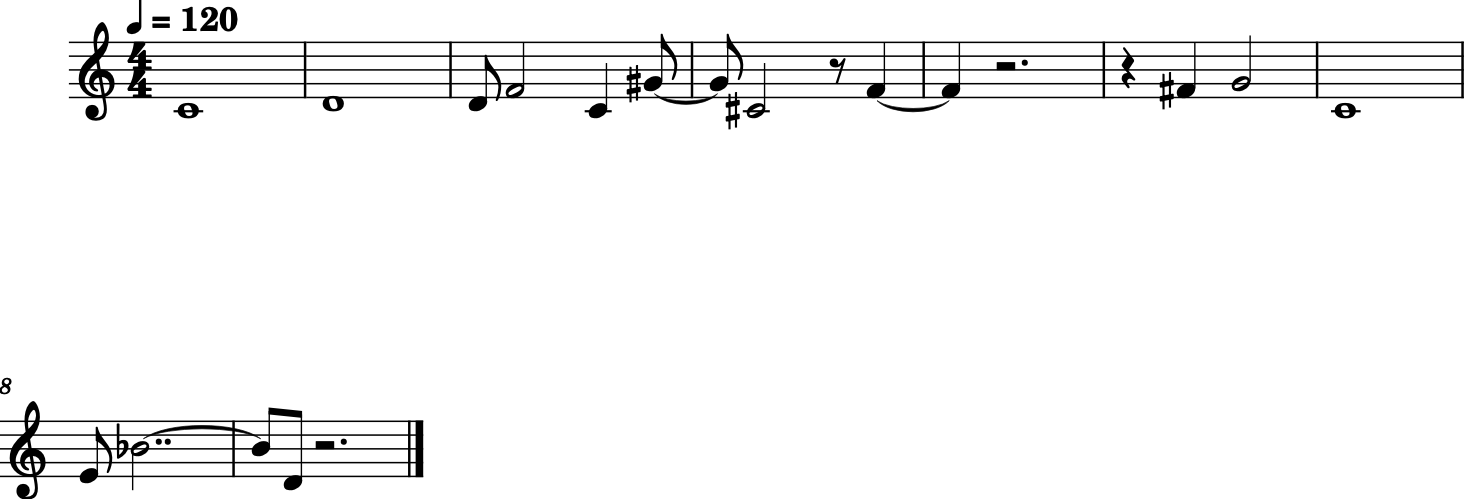

In [5]:
melody = population.individuals[0]
midi_file = melody_to_midi(melody)
score = converter.parse(midi_file)
score.show()
# delete melody.mid file
os.remove("melody.mid")

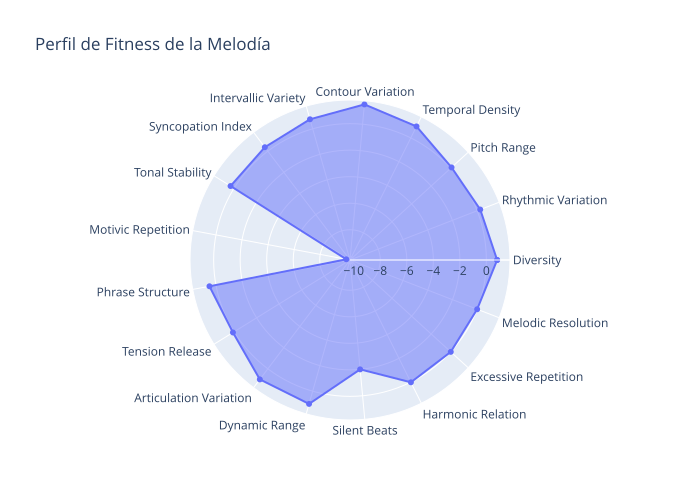

In [6]:
fitness = ScoreFitness()
fitness.plot(melody)

### Algoritmo Genético para la Evolución de Melodías

In [7]:
class MelodyGA(GeneticAlgorithm):
    def __init__(self, *args, **kwargs):
        kwargs['minimize'] = False
        super().__init__(*args, **kwargs)

In [8]:
ga = MelodyGA(
    fitness_function=fitness.fitness_function,
    selection_function=selection.tournament,
    crossover_function=MelodyOperators.crossover,
    mutation_function=MelodyOperators.mutation,
    crossover_rate=0.7,
    mutation_rate=0.1,
    encoder=MelodyEncoding(note_range=(60, 72), length=128),
    elitism=0.1
)

In [9]:
ga.run(generations=500)

Output()

#### Convergencia del Algoritmo Genético

Podemos ver que el algoritmo genético converge correctamente, mejorando la aptitud promedio de la población a lo largo de las generaciones. Esto indica que las melodías generadas evolucionan hacia soluciones más "agradables" según los criterios definidos enteramente por la función objetivo. Es notable que algunos criterios mejoran más rápidamente que otros, lo que sugiere que ciertos aspectos musicales son más fáciles de optimizar mediante el proceso evolutivo. De hecho observamos que la diversidad y la variación rítmica tienden a mejorar rápidamente, mientras que aspectos como la estabilidad tonal y la estructura de frases muestran una mejora más gradual. Esto podría deberse a la complejidad inherente de estos aspectos musicales, que requieren una mayor coherencia y organización en la melodía. Esto se nota en que el alhoritmos parte también de valores negativos que son las penalizaciones por no cumplir ciertos criterios, como los silencios o la repetición excesiva en la función objetivo.

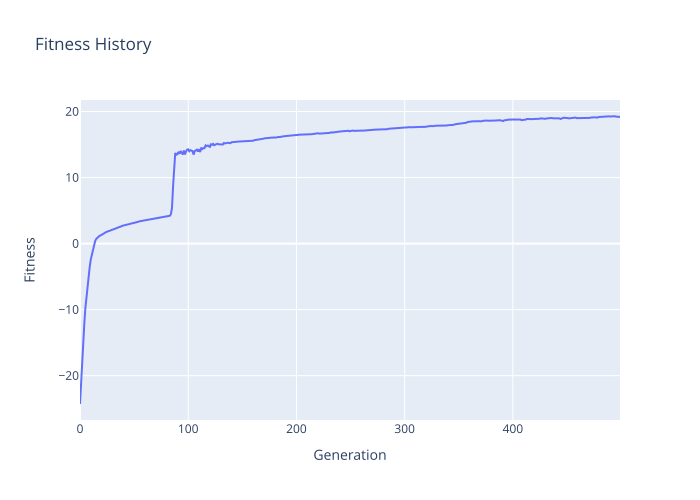

In [10]:
ga.fitness_plot()

In [11]:
ga.best_individual.shape

(128, 2)

#### Renderizado de la Melodía Final

MIDI file saved to: /Users/roicort/GitHub/MetaZoo/playgrounds/viEvolvedi/generated/melody_03-12-25-16.12.mid


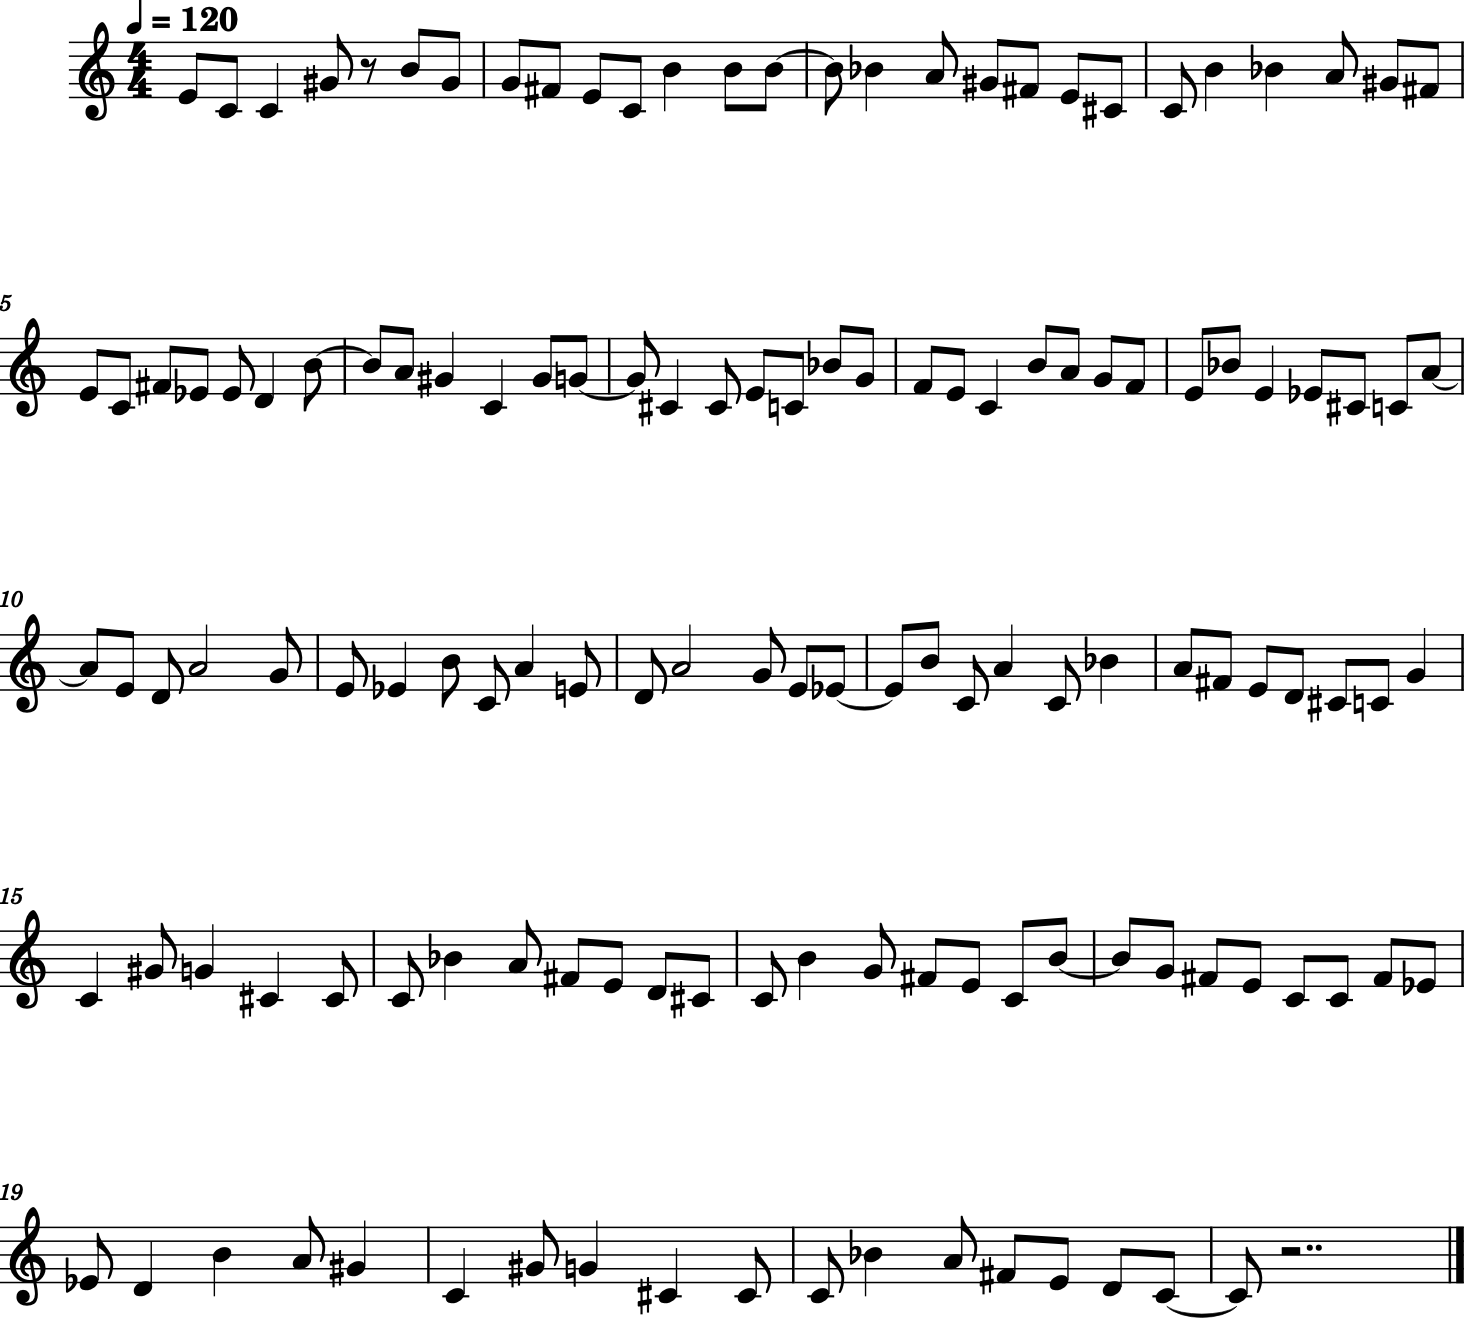

In [12]:
from datetime import datetime

melody = ga.best_individual
date = datetime.now().strftime("%d-%m-%y-%H.%M")
midi_path = os.path.join(SAVE_PATH, f"melody_{date}.mid")
midi_file = melody_to_midi(melody, filename=midi_path)
print(f"MIDI file saved to: {midi_path}")
score = converter.parse(midi_file)
score.show()

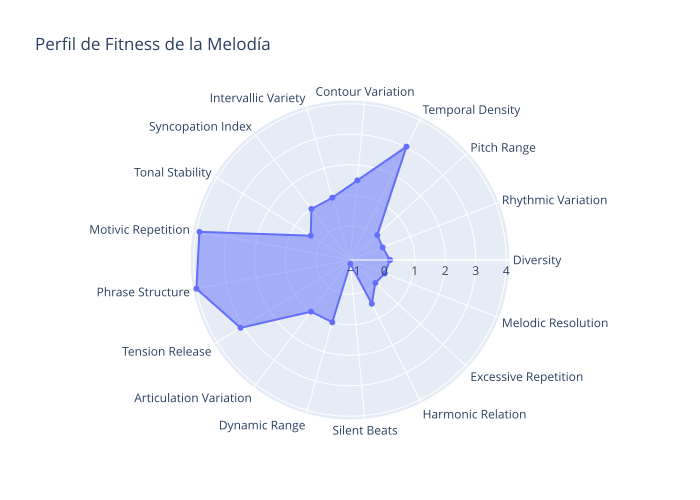

In [13]:
fitness.plot(melody)

#### Opcional: Conversión de MIDI a Audio

In [14]:
#from midi2audio import FluidSynth
#import os

#soundfont_path = "/opt/homebrew/Cellar/fluid-synth/2.5.1/share/soundfonts/default.sf2"

#fs = FluidSynth(sound_font=soundfont_path)
#fs.midi_to_audio(midi_path, midi_path.replace('.mid', '.flac'))

## Herramienta Creativa 

ViEVOLVEdi puede ser utilizado como una herramienta creativa para compositores que buscan inspiración o desean explorar nuevas ideas melódicas. 

Si bien esta propuesta tiene sus limitaciones como la subjetividad en la evaluación musical, la complejidad de capturar todos los matices de la música y no es capaz de componer en si misma reemplazando la creatvidad humana, ofrece un herramienta que sí puede complementarla al proporcionar nuevas posibilidades melódicas y fungir como asistencia de composición.

En este proyecto se ofrece también una herramienta web para la generación de melodías evolutivas utilizando ViEVOLVEdi. Esta herramienta permite a los usuarios configurar parámetros del algoritmo genético y generar melodías de manera interactiva, facilitando su uso como asistente de composición musical. Se puede encontrar en el siguiente enlace: [ViEVOLVEdi Web App](https://playgrounds.unknowable.xyz)